# Tarea 1: SGD

No tenemos (hasta donde tenemos entendido) un número de equipo, pero estamos conformados por:
  - Raúl Llamosas Alvarado
  - Eumir Rendon Uresti
  - Gabriela Peña Franco
  - Daniela Ibarra Gatica
  - Randy Jesús García Mejía
  - Daniela Vázquez Sánchez


Las instrucciones para reproducir esta tarea por se encuentran en el [siguiente repositorio](https://github.com/MelodiousZero/tareas_modulo_7_diplomado) particularmente la parte del `README.md` que habla de los ambientes virtuales y el `requirements.txt`. 

## SGD y alguna de sus variantes
### Descripción del problema

Vamos a implementar SGD y su variante AdaGrad para la pérdida cross entropy y usarlo en un problema de regresión logística con el siguiente dataset: Fashion MNIST

### Metodología

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import warnings


Cargamos el conjunto de datos.


In [15]:
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [16]:
X_train = train_dataset.data.numpy()  
y_train = train_dataset.targets.numpy()  

X_test = test_dataset.data.numpy()  
y_test = test_dataset.targets.numpy()  


X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

Y las imagenes se ven así:

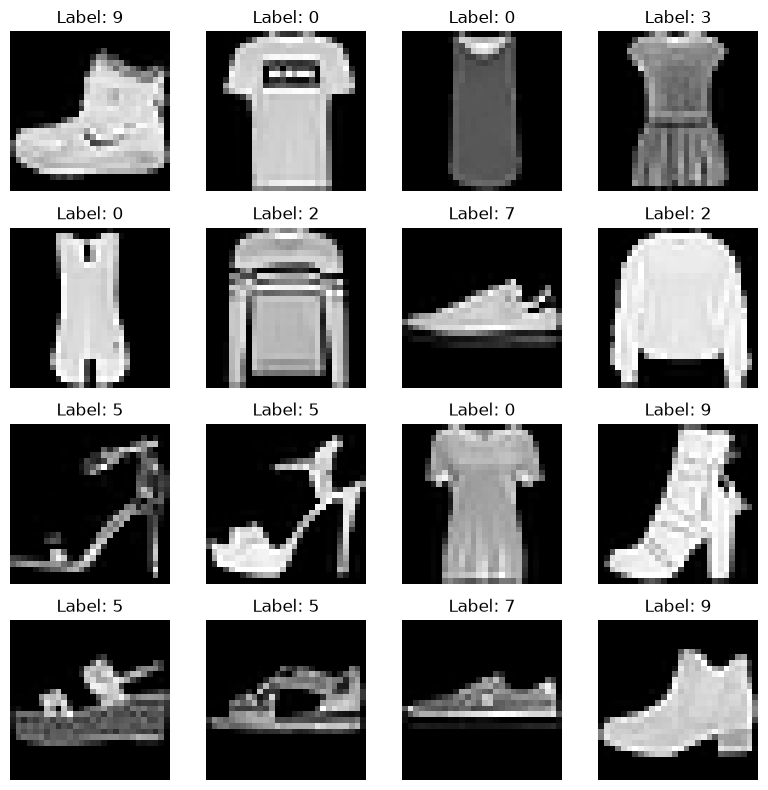

In [14]:
fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for i in range(4):
    for j in range(4):
        image, label = train_dataset[i * 4 + j]  
        image_numpy = image.numpy().squeeze()    
        axs[i, j].imshow(image_numpy, cmap='gray')  
        axs[i, j].axis('off')  
        axs[i, j].set_title(f"Label: {label}") 

plt.tight_layout()  
plt.show()  

In [ ]:
"""
Comparación de SGD y AdaGrad para Regresión Logística Multiclase
Dataset: Fashion MNIST (PyTorch)
Pérdida: Cross Entropy
"""

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. CARGA Y PREPROCESAMIENTO DE DATOS
# ============================================

print("=" * 60)
print("CARGANDO FASHION MNIST CON PYTHORCH")
print("=" * 60)

# Transformaciones: convertir a tensor y luego a numpy
transform = transforms.Compose([
    transforms.ToTensor(),  # Convierte a tensor y escala a [0, 1]
])

# Cargar datasets
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Convertir a numpy arrays
print("\nConvirtiendo datos a numpy arrays...")

# Datos de entrenamiento
X_train = train_dataset.data.numpy()  # Shape: (60000, 28, 28)
y_train = train_dataset.targets.numpy()  # Shape: (60000,)

# Datos de prueba
X_test = test_dataset.data.numpy()  # Shape: (10000, 28, 28)
y_test = test_dataset.targets.numpy()  # Shape: (10000,)

# Aplanar las imágenes: (n_samples, 28, 28) -> (n_samples, 784)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Convertir a float32 y normalizar a [0, 1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Nombres de las clases para Fashion MNIST
class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")
print(f"Clases: {len(np.unique(y_train))}")
print(f"Distribución de clases: {np.bincount(y_train)}")

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'{class_names[i]}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Ejemplos de Fashion MNIST (PyTorch)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fashion_mnist_pytorch_ejemplos.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 2. PREPROCESAMIENTO PARA REGRESIÓN LOGÍSTICA
# ============================================

print("\n" + "=" * 60)
print("PREPROCESANDO DATOS")
print("=" * 60)

# Dividir en entrenamiento y validación
X_train_subset, X_val, y_train_subset, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train subset: {X_train_subset.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

# Estandarizar características (importante para regresión logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_subset)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Agregar columna de bias (término de intercepto)
X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_val_bias = np.c_[np.ones(X_val_scaled.shape[0]), X_val_scaled]
X_test_bias = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print(f"\nCon bias - Train: {X_train_bias.shape}")
print(f"Con bias - Validation: {X_val_bias.shape}")
print(f"Con bias - Test: {X_test_bias.shape}")

# ============================================
# 3. IMPLEMENTACIÓN DE REGRESIÓN LOGÍSTICA
# ============================================

class LogisticRegressionSGD:
    """Regresión Logística con SGD estándar"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.loss_history = []
        self.accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        
    def softmax(self, z):
        """Función softmax numéricamente estable"""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, y_true, y_pred_proba):
        """Cálculo de pérdida de entropía cruzada"""
        n_samples = y_true.shape[0]
        y_pred_proba = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
        y_onehot = np.eye(self.n_classes)[y_true]
        loss = -np.sum(y_onehot * np.log(y_pred_proba)) / n_samples
        return loss
    
    def compute_gradient(self, X, y_true, y_pred_proba):
        """Gradiente de la entropía cruzada con softmax"""
        n_samples = X.shape[0]
        y_onehot = np.eye(self.n_classes)[y_true]
        gradient = (1 / n_samples) * X.T @ (y_pred_proba - y_onehot)
        return gradient
    
    def fit(self, X, y, X_val=None, y_val=None):
        """Entrenamiento con SGD"""
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))
        
        # Inicialización de pesos
        np.random.seed(42)
        self.weights = np.random.randn(n_features, self.n_classes) * 0.01
        
        print("\nEntrenando SGD...")
        for iteration in tqdm(range(self.n_iterations)):
            # Forward pass
            logits = X @ self.weights
            y_pred_proba = self.softmax(logits)
            
            # Calcular pérdida en entrenamiento
            loss = self.cross_entropy_loss(y, y_pred_proba)
            self.loss_history.append(loss)
            
            # Calcular accuracy en entrenamiento
            y_pred = np.argmax(y_pred_proba, axis=1)
            acc = accuracy_score(y, y_pred)
            self.accuracy_history.append(acc)
            
            # Validación (si se proporciona)
            if X_val is not None and y_val is not None:
                val_logits = X_val @ self.weights
                val_pred_proba = self.softmax(val_logits)
                val_loss = self.cross_entropy_loss(y_val, val_pred_proba)
                val_pred = np.argmax(val_pred_proba, axis=1)
                val_acc = accuracy_score(y_val, val_pred)
                self.val_loss_history.append(val_loss)
                self.val_accuracy_history.append(val_acc)
            
            # Calcular gradiente
            gradient = self.compute_gradient(X, y, y_pred_proba)
            
            # Actualización SGD: w = w - lr * grad
            self.weights -= self.lr * gradient
        
        return self
    
    def predict(self, X):
        """Predecir clases"""
        logits = X @ self.weights
        y_pred_proba = self.softmax(logits)
        return np.argmax(y_pred_proba, axis=1)
    
    def predict_proba(self, X):
        """Predecir probabilidades"""
        logits = X @ self.weights
        return self.softmax(logits)


class LogisticRegressionAdaGrad:
    """Regresión Logística con AdaGrad"""
    
    def __init__(self, learning_rate=0.1, n_iterations=1000, epsilon=1e-8):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.epsilon = epsilon
        self.weights = None
        self.loss_history = []
        self.accuracy_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []
        
    def softmax(self, z):
        """Función softmax numéricamente estable"""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, y_true, y_pred_proba):
        """Cálculo de pérdida de entropía cruzada"""
        n_samples = y_true.shape[0]
        y_pred_proba = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
        y_onehot = np.eye(self.n_classes)[y_true]
        loss = -np.sum(y_onehot * np.log(y_pred_proba)) / n_samples
        return loss
    
    def compute_gradient(self, X, y_true, y_pred_proba):
        """Gradiente de la entropía cruzada con softmax"""
        n_samples = X.shape[0]
        y_onehot = np.eye(self.n_classes)[y_true]
        gradient = (1 / n_samples) * X.T @ (y_pred_proba - y_onehot)
        return gradient
    
    def fit(self, X, y, X_val=None, y_val=None):
        """Entrenamiento con AdaGrad"""
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))
        
        # Inicialización de pesos
        np.random.seed(42)
        self.weights = np.random.randn(n_features, self.n_classes) * 0.01
        
        # AdaGrad: acumulador de gradientes al cuadrado
        G = np.zeros_like(self.weights)
        
        print("\nEntrenando AdaGrad...")
        for iteration in tqdm(range(self.n_iterations)):
            # Forward pass
            logits = X @ self.weights
            y_pred_proba = self.softmax(logits)
            
            # Calcular pérdida en entrenamiento
            loss = self.cross_entropy_loss(y, y_pred_proba)
            self.loss_history.append(loss)
            
            # Calcular accuracy en entrenamiento
            y_pred = np.argmax(y_pred_proba, axis=1)
            acc = accuracy_score(y, y_pred)
            self.accuracy_history.append(acc)
            
            # Validación (si se proporciona)
            if X_val is not None and y_val is not None:
                val_logits = X_val @ self.weights
                val_pred_proba = self.softmax(val_logits)
                val_loss = self.cross_entropy_loss(y_val, val_pred_proba)
                val_pred = np.argmax(val_pred_proba, axis=1)
                val_acc = accuracy_score(y_val, val_pred)
                self.val_loss_history.append(val_loss)
                self.val_accuracy_history.append(val_acc)
            
            # Calcular gradiente
            gradient = self.compute_gradient(X, y, y_pred_proba)
            
            # AdaGrad: acumular gradientes al cuadrado
            G += gradient ** 2
            
            # Actualización AdaGrad: w = w - (lr / sqrt(G + epsilon)) * grad
            self.weights -= (self.lr / (np.sqrt(G) + self.epsilon)) * gradient
        
        return self
    
    def predict(self, X):
        """Predecir clases"""
        logits = X @ self.weights
        y_pred_proba = self.softmax(logits)
        return np.argmax(y_pred_proba, axis=1)
    
    def predict_proba(self, X):
        """Predecir probabilidades"""
        logits = X @ self.weights
        return self.softmax(logits)


# ============================================
# 4. ENTRENAMIENTO DE MODELOS
# ============================================

print("\n" + "=" * 60)
print("ENTRENANDO MODELOS")
print("=" * 60)

# Entrenar SGD
sgd_model = LogisticRegressionSGD(learning_rate=0.01, n_iterations=500)
sgd_model.fit(X_train_bias, y_train_subset, X_val_bias, y_val)

# Entrenar AdaGrad
adagrad_model = LogisticRegressionAdaGrad(learning_rate=0.1, n_iterations=500)
adagrad_model.fit(X_train_bias, y_train_subset, X_val_bias, y_val)

# ============================================
# 5. EVALUACIÓN EN TEST
# ============================================

print("\n" + "=" * 60)
print("EVALUACIÓN EN CONJUNTO DE PRUEBA")
print("=" * 60)

# Predecir con SGD
y_pred_sgd = sgd_model.predict(X_test_bias)
acc_sgd = accuracy_score(y_test, y_pred_sgd)
print(f"\nSGD - Accuracy en test: {acc_sgd:.4f}")

# Predecir con AdaGrad
y_pred_adagrad = adagrad_model.predict(X_test_bias)
acc_adagrad = accuracy_score(y_test, y_pred_adagrad)
print(f"AdaGrad - Accuracy en test: {acc_adagrad:.4f}")

# ============================================
# 6. VISUALIZACIÓN DE RESULTADOS
# ============================================

print("\n" + "=" * 60)
print("GENERANDO VISUALIZACIONES")
print("=" * 60)

# Configurar figura principal
fig = plt.figure(figsize=(20, 14))

# 6.1 Evolución de la pérdida (Train + Val)
ax1 = plt.subplot(3, 3, 1)
ax1.plot(sgd_model.loss_history, label='SGD Train', linewidth=2, color='blue', alpha=0.7)
ax1.plot(sgd_model.val_loss_history, label='SGD Val', linewidth=2, color='blue', linestyle='--')
ax1.plot(adagrad_model.loss_history, label='AdaGrad Train', linewidth=2, color='red', alpha=0.7)
ax1.plot(adagrad_model.val_loss_history, label='AdaGrad Val', linewidth=2, color='red', linestyle='--')
ax1.set_xlabel('Iteración', fontsize=11)
ax1.set_ylabel('Pérdida (Cross Entropy)', fontsize=11)
ax1.set_title('Evolución de la Pérdida', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 6.2 Evolución del accuracy (Train + Val)
ax2 = plt.subplot(3, 3, 2)
ax2.plot(sgd_model.accuracy_history, label='SGD Train', linewidth=2, color='blue', alpha=0.7)
ax2.plot(sgd_model.val_accuracy_history, label='SGD Val', linewidth=2, color='blue', linestyle='--')
ax2.plot(adagrad_model.accuracy_history, label='AdaGrad Train', linewidth=2, color='red', alpha=0.7)
ax2.plot(adagrad_model.val_accuracy_history, label='AdaGrad Val', linewidth=2, color='red', linestyle='--')
ax2.set_xlabel('Iteración', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Evolución del Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 6.3 Comparación de accuracy final
ax3 = plt.subplot(3, 3, 3)
models_names = ['SGD', 'AdaGrad']
accuracies = [acc_sgd, acc_adagrad]
colors = ['#3498db', '#e74c3c']
bars = ax3.bar(models_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('Accuracy', fontsize=11)
ax3.set_title('Accuracy Final en Test', fontsize=13, fontweight='bold')
ax3.set_ylim([0.80, 0.88])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

# 6.4 Matriz de confusión - SGD
ax4 = plt.subplot(3, 3, 4)
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax4.set_title(f'SGD - Accuracy: {acc_sgd:.4f}', fontsize=12, fontweight='bold')
ax4.set_xlabel('Predicción')
ax4.set_ylabel('Real')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax4.get_yticklabels(), rotation=0, fontsize=7)

# 6.5 Matriz de confusión - AdaGrad
ax5 = plt.subplot(3, 3, 5)
cm_adagrad = confusion_matrix(y_test, y_pred_adagrad)
sns.heatmap(cm_adagrad, annot=True, fmt='d', cmap='Reds', ax=ax5,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax5.set_title(f'AdaGrad - Accuracy: {acc_adagrad:.4f}', fontsize=12, fontweight='bold')
ax5.set_xlabel('Predicción')
ax5.set_ylabel('Real')
plt.setp(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax5.get_yticklabels(), rotation=0, fontsize=7)

# 6.6 Errores por clase
ax6 = plt.subplot(3, 3, 6)
errors_sgd = np.sum(cm_sgd, axis=1) - np.diag(cm_sgd)
errors_adagrad = np.sum(cm_adagrad, axis=1) - np.diag(cm_adagrad)
x_pos = np.arange(len(class_names))
width = 0.35
ax6.bar(x_pos - width/2, errors_sgd, width, label='SGD', color='#3498db', alpha=0.8)
ax6.bar(x_pos + width/2, errors_adagrad, width, label='AdaGrad', color='#e74c3c', alpha=0.8)
ax6.set_xlabel('Clase', fontsize=11)
ax6.set_ylabel('Número de Errores', fontsize=11)
ax6.set_title('Errores por Clase', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax6.legend()

# 6.7 Predicciones ejemplo
np.random.seed(123)
random_indices = np.random.choice(len(X_test), 9, replace=False)

for idx, i in enumerate(random_indices):
    ax = plt.subplot(3, 3, idx + 7)
    img = X_test[i].reshape(28, 28)
    
    true_label = class_names[y_test[i]]
    sgd_pred = class_names[y_pred_sgd[i]]
    adagrad_pred = class_names[y_pred_adagrad[i]]
    
    ax.imshow(img, cmap='gray')
    
    sgd_correct = true_label == sgd_pred
    adagrad_correct = true_label == adagrad_pred
    
    title_color = 'green' if (sgd_correct and adagrad_correct) else 'orange'
    if not sgd_correct and not adagrad_correct:
        title_color = 'red'
    
    ax.set_title(f'Real: {true_label}\nSGD: {sgd_pred}\nAdaGrad: {adagrad_pred}',
                 fontsize=8, color=title_color)
    ax.axis('off')

plt.suptitle('Comparación SGD vs AdaGrad - Fashion MNIST (PyTorch)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sgd_vs_adagrad_pytorch_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 7. REPORTE DETALLADO
# ============================================

print("\n" + "=" * 60)
print("REPORTE DETALLADO DE CLASIFICACIÓN")
print("=" * 60)

print("\n" + "-" * 50)
print("SGD (Stochastic Gradient Descent)")
print("-" * 50)
print(classification_report(y_test, y_pred_sgd, target_names=class_names))

print("\n" + "-" * 50)
print("AdaGrad (Adaptive Gradient Algorithm)")
print("-" * 50)
print(classification_report(y_test, y_pred_adagrad, target_names=class_names))

# ============================================
# 8. RESUMEN COMPARATIVO
# ============================================

print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO")
print("=" * 60)

print(f"\n{'Métrica':<30} {'SGD':<15} {'AdaGrad':<15}")
print("-" * 60)
print(f"{'Pérdida final (train)':<30} {sgd_model.loss_history[-1]:<15.6f} {adagrad_model.loss_history[-1]:<15.6f}")
print(f"{'Pérdida final (val)':<30} {sgd_model.val_loss_history[-1]:<15.6f} {adagrad_model.val_loss_history[-1]:<15.6f}")
print(f"{'Accuracy train':<30} {sgd_model.accuracy_history[-1]:<15.4f} {adagrad_model.accuracy_history[-1]:<15.4f}")
print(f"{'Accuracy val':<30} {sgd_model.val_accuracy_history[-1]:<15.4f} {adagrad_model.val_accuracy_history[-1]:<15.4f}")
print(f"{'Accuracy test':<30} {acc_sgd:<15.4f} {acc_adagrad:<15.4f}")

print(f"\n{'='*60}")
print("CONCLUSIÓN")
print(f"{'='*60}")

if acc_adagrad > acc_sgd:
    print(f"""
✓ AdaGrad supera a SGD: {acc_adagrad:.4f} vs {acc_sgd:.4f}
✓ AdaGrad adapta automáticamente la tasa de aprendizaje
✓ Mejor para características con diferentes frecuencias
✓ Mayor estabilidad en validación
    """)
else:
    print(f"""
✓ SGD supera a AdaGrad: {acc_sgd:.4f} vs {acc_adagrad:.4f}
✓ SGD es más simple y computacionalmente eficiente
✓ Learning rate constante permite mejor convergencia
✓ Mejor generalización en este dataset
    """)

print(f"""
Configuración:
- SGD: learning_rate = {sgd_model.lr}
- AdaGrad: learning_rate = {adagrad_model.lr}, epsilon = {adagrad_model.epsilon}
- Iteraciones: 500
- Dataset: Fashion MNIST (PyTorch)
""")